In [19]:
import os, string

import pandas as pd
import numpy as np
import itertools
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import ScaledTranslation
from pathlib import Path

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = "Avenir"
#mpl.rcParams['pdf.fonttype']        = 42

#mpl.rcParams.update({"pdf.use14corefonts": True})

path_to_scenarios = '/Users/Guille/Desktop/india_power/scenarios'
path_to_images    = '/Users/Guille/Desktop/india_power/images'
path_to_csvs      = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_tables    = '/Users/Guille/Desktop/india_power/tables'
path_to_inputs    = '/Users/Guille/Desktop/india_power/input_data'
path_to_data      = '/Users/Guille/Desktop/india_power/gridpath_india_viz/data/' 

# Battery power and energy capacity review

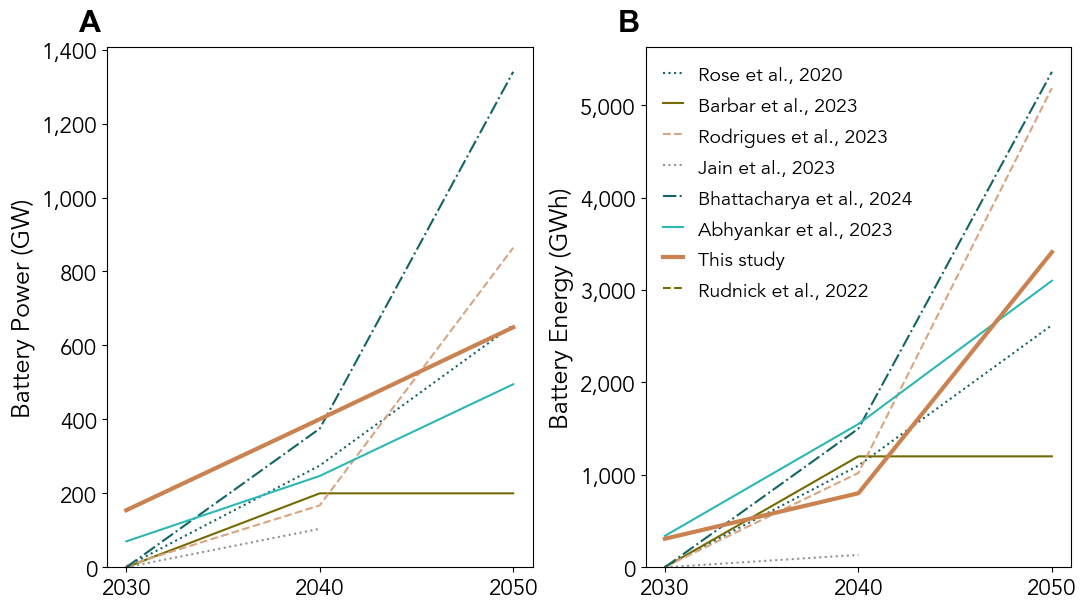

In [3]:
df_ = pd.read_csv(path_to_data + 'studies_bess_capacity.csv')
df_ = df_.dropna()

fig, _ax = plt.subplot_mosaic([['A', 'B']], 
                              layout      = 'constrained', 
                              figsize     = (10.75, 6), 
                              gridspec_kw = {'width_ratios': [1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
                             fontsize  = 22, 
                             weight    = "bold",
                             va        = 'bottom',
                             family    = 'Arial')

def _plot_studies_bess_comparison(_ax, df_, column,
                                  ylabel = 'Installation Rate (GW/yr)', 
                                  units = 1000):
    
    for study in df_['study'].unique():
        df_p_ = df_.loc[df_['study'] == study].reset_index(drop = True)
        x_ = df_p_['period'].to_numpy().astype(int)
        y_ = df_p_[column].to_numpy()
    
        _ax.plot(x_, y_/units, 
                 label = study, 
                 color = df_p_['color'].to_numpy()[0],
                 lw    = df_p_['lw'].to_numpy()[0],
                 ls    = df_p_['ls'].to_numpy()[0])
    
    _ax.set_ylabel(ylabel, size = 18)
    _ax.tick_params(labelsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    x_ = [2030, 2040, 2050]
    _ax.set_xticks(x_, x_)
    _ax.set_ylim(0,)
    #_ax.set_xlim(x_[0], x_[-1])

_plot_studies_bess_comparison(_ax['A'], df_, 
                              column = 'capacity_mw',
                              ylabel = 'Battery Power (GW)')
    

_plot_studies_bess_comparison(_ax['B'], df_, 
                              column = 'capacity_mwh',
                              ylabel = 'Battery Energy (GWh)')
    

_ax['B'].legend(frameon        = False, 
                #title          = "Study", 
                fontsize       = 14, 
                title_fontsize = 16)

plt.savefig(path_to_images + f'/SI-battery_studies_comparison.png', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

# Solar and wind installation rate

[2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]
[3.880000e+00 2.639000e+01 9.089200e+02 7.451300e+02 1.135470e+03
 1.171620e+03 3.130360e+03 5.658630e+03 9.563690e+03 6.750970e+03
 6.510060e+03 5.628780e+03 1.276052e+04 1.278382e+04 1.503324e+04
 2.383289e+04]


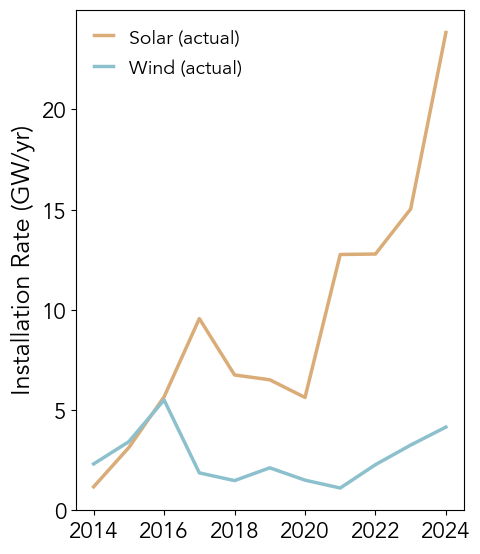

In [20]:
df_ = pd.read_excel(path_to_inputs + '/generators/2007-2025_national_capacity.xlsx', sheet_name = 0)  

df_solar_ = df_.loc[df_.Parameter.str.contains('Solar')].reset_index(drop = True)
df_wind_  = df_.loc[df_.Parameter.str.contains('Wind')].reset_index(drop = True)

period_ = df_solar_.columns.to_numpy()[1:]
period_ = np.array([int(period[:2] + period[-2:]) for period in period_])

df_solar_ = df_solar_.fillna(0.).sum(axis=0, numeric_only=True).to_numpy()
df_wind_  = df_wind_.fillna(0.).sum(axis=0, numeric_only=True).to_numpy()

period_        = period_[1:-1]
df_solar_rate_ = np.diff(df_solar_)[1:]#/df_solar_[1:-1]
df_wind_rate_  = np.diff(df_wind_)[1:]#/df_wind_[1:-1]
print(period_)
print(df_solar_rate_)

fig, _ax = plt.subplots(figsize = (5, 6.5))

_ax.plot(period_[5:], df_solar_rate_[5:]/1000, 
         label = 'Solar (actual)', 
         lw = 2.5, 
         c = '#daac77')

_ax.plot(period_[5:], 
         df_wind_rate_[5:]/1000, 
         label = 'Wind (actual)', 
         lw = 2.5, 
         c = '#8dc0cd')

_ax.set_xticks(period_[5::2], period_[5::2])
plt.legend(frameon = False, fontsize = 14)

_ax.set_ylabel('Installation Rate (GW/yr)', size = 18)
_ax.tick_params(labelsize = 16)
#_ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
_ax.set_ylim(0,)

plt.savefig(path_to_images + f'/SI-installation_rate.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

In [21]:
# Grab data from databases for plotting new and existing capacity
def _load_capacity(scen_labels_):

    # Load project capacity table and process them from database
    def __load_new_and_existing_csv(df_, scenario):

        df_p_  = df_[['period', 
                      'technology',
                      'load_zone', 
                      'capacity_mw']].copy()

        df_p_ = df_p_.groupby(['period', 
                               'technology', 
                               'load_zone']).agg('sum').reset_index(drop = False)

        df_p_['scenario'] = scenario

        return df_p_
    
    dfs_ = []
    # Open connection: open database and grab meta-data
    for scen, path in zip(scen_labels_['scenario'],  scen_labels_['path']):
        print(scen, path)
        dir_name  = r'{}/{}'.format(path, scen)
        capacity_ = pd.read_csv(dir_name + r'/results/project_period.csv', low_memory = False)
        df_       = __load_new_and_existing_csv(capacity_, scen)
        
        # Load specified capacity from csv files
        dfs_.append(df_)

    return pd.concat(dfs_, axis = 0).reset_index(drop = True)

# Grab data from databases for plotting energy dispatch and clean energy targets
def _load_dispatch(scen_labels_):

    # Load energy dispatch table and process data from database
    def __load_dispatch_from_csv(df_, scenario):

        df_['dispatch_mw']  = df_['power_mw'] * df_['timepoint_weight'] * df_['number_of_hours_in_timepoint']
        df_['potential_mw'] = df_['capacity_mw'] * df_['timepoint_weight'] * df_['number_of_hours_in_timepoint']

        df_ = df_[['period', 
                   'timepoint',
                   'technology', 
                   'load_zone', 
                   'dispatch_mw', 
                   'potential_mw']]

        df_ = df_.groupby(['period', 
                           'timepoint',
                           'technology', 
                           'load_zone']).agg({'dispatch_mw': 'sum',
                                              'potential_mw': 'sum'}).reset_index(drop = False)
         
        df_['scenario'] = scenario
                
        return df_

    dfs_ = []
    # Open connection: open database and grab meta-data
    for scen, path in zip(scen_labels_['scenario'], scen_labels_['path']):
        print(scen, path)
        
        dir_name  = r'{}/{}'.format(path, scen)
        dispatch_ = pd.read_csv(dir_name + f'/results/project_timepoint.csv', low_memory = False)
        
        dfs_ += [__load_dispatch_from_csv(dispatch_, scen)]

    return pd.concat(dfs_, axis = 0).reset_index(drop = True)

def _group_capacity_technologies(capacity_, tech_labels_):

    for group in tech_labels_['group'].unique():
        capacity_.loc[capacity_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    capacity_ = capacity_.groupby(['period', 
                                   'technology', 
                                   'load_zone', 
                                   'scenario']).agg('sum')

    return capacity_.reset_index(drop = False)

def _group_dispatch_technologies(dispatch_, tech_labels_):

    for group in tech_labels_['group'].unique():
        dispatch_.loc[dispatch_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    dispatch_ = dispatch_.groupby(['period', 
                                   'timepoint',
                                   'technology', 
                                   'load_zone', 
                                   'scenario']).agg('sum')

    return dispatch_.reset_index(drop = False)

In [22]:
scen_labels_ = pd.read_csv(path_to_csvs + '/cost-scenario_labels.csv') 
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
zone_labels_ = pd.read_csv(path_to_csvs + '/zone_labels.csv') 
print(scen_labels_)

  zone                                           scenario  \
0  all  VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...   
1  all  VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90C...   
2  all  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...   
3  all  VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90C...   
4  all  VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90...   
5  all  VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_9...   

                              label    color linestyle  linewidth  order  \
0        VRE & ESS (low) Coal (low)  #92918b     solid        1.5     10   
1       VRE & ESS (low) Coal (high)  #136564    dashed        1.5     10   
2  VRE & ESS (mid) Coal (low) - REF  #ca8250     solid        3.0      9   
3       VRE & ESS (mid) Coal (high)  #2cb7b5    dotted        1.5     10   
4       VRE & ESS (high) Coal (low)  #756a01   dashdot        1.5     10   
5      VRE & ESS (high) Coal (high)  #d8a581    dashed        1.5     10   

  marker                               

In [23]:
scen_labels_ = pd.read_csv(path_to_csvs + '/pier-scenario_labels.csv') 
print(scen_labels_['scenario'].unique())
capacity_ = _load_capacity(scen_labels_)

grouped_state_capacity_  = _group_capacity_technologies(capacity_, tech_labels_)

idx_ = (grouped_state_capacity_['technology'] == 'Wind') | (grouped_state_capacity_['technology'] == 'Solar')
grouped_state_capacity_  = grouped_state_capacity_.loc[idx_]
grouped_system_capacity_ = grouped_state_capacity_.groupby(['period', 
                                                            'technology', 
                                                            'scenario']).agg({'capacity_mw': 'sum'}).reset_index(drop = False)

df_1_ = grouped_system_capacity_.loc[grouped_system_capacity_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'].reset_index(drop = True)
df_2_ = grouped_system_capacity_.loc[grouped_system_capacity_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'].reset_index(drop = True)

y_solar_1_ = df_1_.loc[df_1_['technology'] == 'Solar', 'capacity_mw'].to_numpy()
y_wind_1_  = df_1_.loc[df_1_['technology'] == 'Wind', 'capacity_mw'].to_numpy()

y_solar_2_ = df_2_.loc[df_2_['technology'] == 'Solar', 'capacity_mw'].to_numpy()
y_wind_2_  = df_2_.loc[df_2_['technology'] == 'Wind', 'capacity_mw'].to_numpy()

x_1_ = df_1_['period'].unique()
x_2_ = df_2_['period'].unique()

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid']
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid /Users/Guille/Desktop/india_power/scenarios/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/pier


(152, 4)


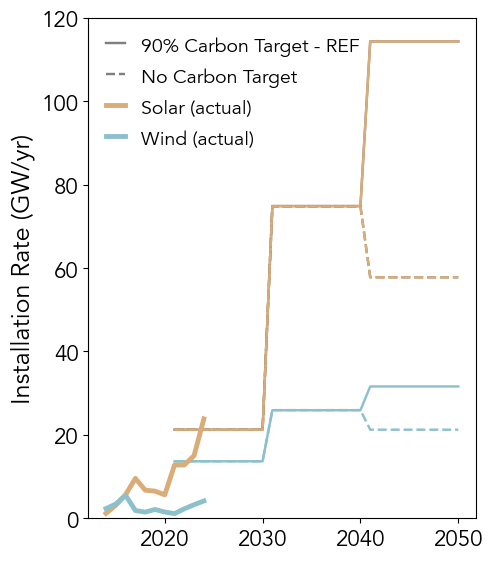

In [47]:
def _constant_rate(x_, y_):

    dx_ = np.diff(x_)
    dy_ = np.diff(y_)/dx_
    x_p_ = np.arange(x_[-1] - x_[0]) + 2021
    y_p_ = np.zeros(x_[-1] - x_[0])

    k = 0
    for i in range(dy_.shape[0]):
        for j in range(dx_[i]):
            y_p_[k] = dy_[i]
            k += 1
    return x_p_, y_p_

x_1_p_, y_solar_1_p_ = _constant_rate(x_1_, y_solar_1_)
x_2_p_, y_solar_2_p_ = _constant_rate(x_2_, y_solar_2_)

x_1_p_, y_wind_1_p_ = _constant_rate(x_1_, y_wind_1_)
x_2_p_, y_wind_2_p_ = _constant_rate(x_2_, y_wind_2_)

fig, _ax = plt.subplots(figsize = (5, 6.5))

_ax.plot(x_2_p_, 
         y_solar_2_p_/1000, 
         label = '90% Carbon Target - REF',
         ls = '-',
         lw = 1.75, 
         c = 'gray')

_ax.plot(x_2_p_, y_solar_2_p_/1000, 
         lw = 1.75, 
         ls = '-',
         c = '#daac77')

_ax.plot(x_2_p_, y_wind_2_p_/1000, 
         lw = 1.75, 
         ls = '-',
         c = '#8dc0cd')

X_2_s_ = pd.DataFrame(np.stack([x_2_p_, y_solar_2_p_]).T, columns = ['period', 'new_capacity_mw/yr'])
X_2_w_ = pd.DataFrame(np.stack([x_2_p_, y_wind_2_p_]).T, columns = ['period', 'new_capacity_mw/yr'])

X_2_s_['technology'] = 'solar'
X_2_w_['technology'] = 'wind'
X_2_s_['scenario']   = '90% Carbon Target - REF'
X_2_w_['scenario']   = '90% Carbon Target - REF'

_ax.plot(x_1_p_, 
         y_solar_1_p_/1000, 
         label = 'No Carbon Target',
         ls = '--',
         lw = 1.75, 
         c = 'gray')

_ax.plot(x_1_p_, 
         y_solar_1_p_/1000, 
         ls = '--',
         lw = 1.75, 
         c = '#daac77')

_ax.plot(x_1_p_, 
         y_wind_1_p_/1000, 
         ls = '--',
         lw = 1.75, 
         c = '#8dc0cd')


X_1_s_ = pd.DataFrame(np.stack([x_1_p_, y_solar_1_p_]).T, columns = ['period', 'new_capacity_mw/yr'])
X_1_w_ = pd.DataFrame(np.stack([x_1_p_, y_wind_1_p_]).T, columns = ['period', 'new_capacity_mw/yr'])

X_1_s_['technology'] = 'solar'
X_1_w_['technology'] = 'wind'
X_1_s_['scenario']   = 'No Carbon Target'
X_1_w_['scenario']   = 'No Carbon Target'

_ax.plot(period_[5:], df_solar_rate_[5:]/1000, 
         label = 'Solar (actual)', 
         lw = 3.5, 
         c = '#daac77')

_ax.plot(period_[5:], 
         df_wind_rate_[5:]/1000, 
         label = 'Wind (actual)', 
         lw = 3.5, 
         c = '#8dc0cd')

X_s_ = pd.DataFrame(np.stack([period_, df_solar_rate_]).T, columns = ['period', 'new_capacity_mw/yr'])
X_w_ = pd.DataFrame(np.stack([period_, df_wind_rate_]).T, columns = ['period', 'new_capacity_mw/yr'])

X_s_['technology'] = 'solar'
X_w_['technology'] = 'wind'
X_s_['scenario']   = 'actual'
X_w_['scenario']   = 'actual'

X_ = pd.concat([X_1_s_, X_1_w_, X_2_s_, X_2_w_, X_s_, X_w_], axis = 0)
print(X_.shape)
X_.to_csv('installation_rate.csv', index = False)

#_ax.set_xticks(2010 + np.arange(4, type = int)*10, 2010 + np.arange(4, type = int)*10)
plt.legend(frameon = False, fontsize = 14)

_ax.set_ylabel('Installation Rate (GW/yr)', size = 18)
_ax.tick_params(labelsize = 16)
#_ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
_ax.set_ylim(0,)

plt.savefig(path_to_images + f'/SI-installation_rate.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + f'/SI-installation_rate.png', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

In [9]:
# def _exponential_growth(x_, y_):
        
#     dx_  = np.diff(x_)
#     rho_ = ((y_[1:]/y_[:-1])**(1/dx_) - 1)
    
#     x_p_ = np.zeros((x_[-1] - x_[0] + 1),)
#     y_p_ = np.zeros((x_[-1] - x_[0] + 1),)
#     print(x_p_.shape, y_p_.shape)
    
#     x_p_[0] = x_[0]
#     y_p_[0] = y_[0]
    
#     for i in range(dx_.shape[0]):
#         for j in range(dx_[i]):
#             k = int(i*10 + j + 1)
#             x_p_[k] = x_p_[k - 1] + 1
#             y_p_[k] = y_p_[k - 1] + y_p_[k - 1]*rho_[i]

#     return x_p_, y_p_

# x_1_p_, y_solar_1_p_ = _exponential_growth(x_1_, y_solar_1_)

# plt.figure(figsize = (4, 4))
# plt.plot(x_1_, y_solar_1_/1000)
# plt.plot(x_1_p_, y_solar_1_p_/1000)
# plt.ylabel('Installed Capacity (GW)')
# plt.show()

# plt.figure(figsize = (4, 4))
# plt.ylabel('Installion Rate (GW/yr)')
# plt.plot(x_1_[:-1], np.diff(y_solar_1_)/10000.)
# plt.plot(x_1_p_[1:], np.diff(y_solar_1_p_)/1000.)
# plt.show()

# Rotating innertia provided

In [10]:
scen_labels_ = pd.read_csv(path_to_csvs + '/pcm-scenario_labels.csv') 
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
zone_labels_ = pd.read_csv(path_to_csvs + '/zone_labels.csv') 

scen_labels_ = scen_labels_.loc[scen_labels_.label.str.contains('REF')].reset_index(drop = True)
print(scen_labels_)

  zone                                           scenario  \
0  all  PC2030_1prob_VREmid_STmid_CONVmid_H2_RES_8PRM_...   
1  all  PC2040_1prob_VREmid_STmid_CONVmid_H2_RES_8PRM_...   
2  all  PC2050_1prob_VREmid_STmid_CONVmid_H2_RES_8PRM_...   

                              label    color linestyle  linewidth  order  \
0  VRE & ESS (mid) Coal (low) - REF  #ca8250    dotted        3.0      9   
1  VRE & ESS (mid) Coal (low) - REF  #ca8250    dashed        3.0      9   
2  VRE & ESS (mid) Coal (low) - REF  #ca8250     solid        3.0      9   

  marker                                             path  
0   None  /Users/Guille/Desktop/india_power/scenarios/pcm  
1   None  /Users/Guille/Desktop/india_power/scenarios/pcm  
2   None  /Users/Guille/Desktop/india_power/scenarios/pcm  


In [11]:
# Grab data from databases for plotting energy dispatch and clean energy targets
def _load_inertia(scen_labels_, inertia_technology_):

    # Load energy dispatch table and process data from database
    def __load_inertia_from_csv(dispatch_, system_load_, inertia_technology_):

        dispatch_['power_mw'] = (dispatch_['power_mw'] 
                                 * dispatch_['timepoint_weight'] 
                                 * dispatch_['number_of_hours_in_timepoint'])
        
        system_load_['static_load_mw'] = (system_load_['static_load_mw'] 
                                          * system_load_['timepoint_weight'] 
                                          * system_load_['number_of_hours_in_timepoint'])
        
        dispatch_ = dispatch_.loc[dispatch_['technology'].isin(inertia_technology_)].reset_index(drop = True)
        dispatch_ = dispatch_.loc[dispatch_['power_mw'] > 0].reset_index(drop = True)

        dispatch_ = dispatch_.groupby(['period', 
                                       'timepoint']).agg({'power_mw': 'sum',
                                                          'capacity_mw': 'sum'}).reset_index(drop = False)

        system_load_ = system_load_.groupby(['period', 
                                             'timepoint']).agg({'static_load_mw': 'sum'}).reset_index(drop = False)

        df_ = pd.merge(dispatch_, system_load_, on = ['period', 'timepoint'], how = "right") 
        
        df_['PLF']            = 100.*df_['power_mw']/df_['capacity_mw']
        df_['system_inertia'] = 100.*df_['power_mw']/df_['static_load_mw']

        return df_

    dfs_ = []
    # Open connection: open database and grab meta-data
    for scen, path in zip(scen_labels_['scenario'], scen_labels_['path']):
        print(scen, path)
        
        dir_name  = r'{}/{}'.format(path, scen)
        
        dispatch_    = pd.read_csv(dir_name + f'/results/project_timepoint.csv', low_memory = False)
        system_load_ = pd.read_csv(dir_name + f'/results/system_load_zone_timepoint.csv', low_memory = False)
        
        dfs_ += [__load_inertia_from_csv(dispatch_, system_load_, inertia_technology_)]

    return pd.concat(dfs_, axis = 0).reset_index(drop = True)

inertia_technology_ = ['Biomass', 
                       'CCGT', 
                       'Diesel', 
                       'Hydro_Pumped', 
                       'Hydro_ROR', 
                       'Hydro_Storage', 
                       'Nuclear', 
                       'Subcritical_Coal_Small',
                       'Supercritical_Coal',
                       'Subcritical_Coal_Large',
                       'WHR']

inertia_ = _load_inertia(scen_labels_, inertia_technology_)
print(inertia_.shape)

inertia_.loc[inertia_['system_inertia'] > 100, 'system_inertia'] == 100
inertia_.loc[inertia_['system_inertia'] < 0., 'system_inertia'] == 0.

PC2030_1prob_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup /Users/Guille/Desktop/india_power/scenarios/pcm
PC2040_1prob_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup /Users/Guille/Desktop/india_power/scenarios/pcm
PC2050_1prob_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup /Users/Guille/Desktop/india_power/scenarios/pcm
(26280, 7)


Series([], Name: system_inertia, dtype: bool)

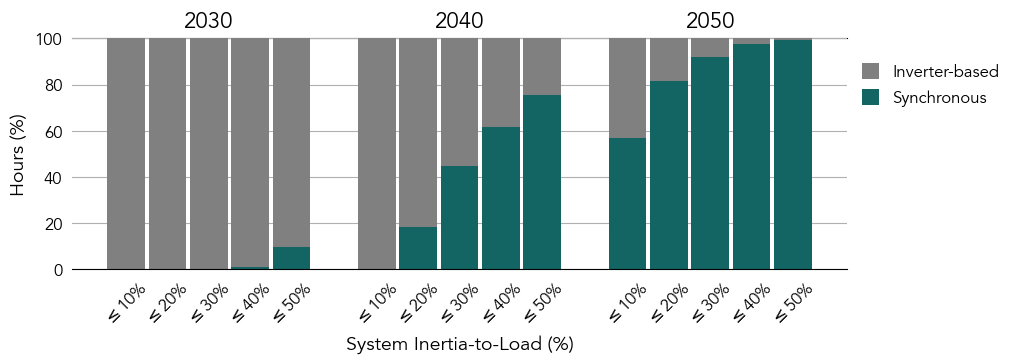

In [12]:
periods_ = inertia_['period'].unique()
colors_ = ['#136564', '#136564', '#136564']
x_ = np.arange(periods_.shape[0])

x_all_ = []
y_all_ = []

fig, _ax = plt.subplots(1, 1, figsize = (10, 3.))

for i in range(periods_.shape[0]):
    df_ = inertia_.loc[inertia_['period'] == periods_[i]].reset_index(drop = True)

    counts_, bins_ = np.histogram(df_['system_inertia'], 
                                  bins = 10, 
                                  range = (0., 100.), 
                                  density = False)
    bins_   = bins_[1:]
    counts_ = 100.*np.cumsum(counts_)/8760
    idx_    = bins_ <= 50
    bins_   = bins_[idx_]
    counts_ = counts_[idx_]

    x_p_ = np.linspace(-0.33, 0.33, counts_.shape[0])

    _ax.bar(x_[i] + x_p_, 100., 
            width = 0.15, 
            color = 'gray',
            zorder = 2)

    _ax.bar(x_[i] + x_p_, counts_, 
            width = 0.15, 
            color = colors_[i],
            zorder = 2)

    x_all_.append(x_[i] + x_p_)
    y_all_.append(bins_)

ax_top = _ax.secondary_xaxis("top")
ax_top.set_xticks(x_, periods_, fontsize = 16)

y_all_label_ = [f'$\leq${int(y)}%' for y in np.concatenate(y_all_, axis = 0)]
_ax.set_xticks(np.concatenate(x_all_, axis = 0), 
               y_all_label_, rotation = 45)

_ax.set_xlabel('System Inertia-to-Load (%)', fontsize = 14)
_ax.set_ylabel('Hours (%)', fontsize = 14)

_ax.xaxis.set_tick_params(labelsize = 12, bottom = False)
_ax.yaxis.set_tick_params(labelsize = 12, left = False)

ax_top.tick_params(axis="x", which="both", length=0)

_ax.bar(0., 0., 0., color  = 'gray',
                   label  = r'Inverter-based')

_ax.bar(0., 0., 0., color  = '#136564',
                   label  = r'Synchronous')

_ax.legend(loc            = 'center left',
          bbox_to_anchor = (1., 0.8),
          frameon        = False,
          prop           = {'size': 12})

# ax.set_xlim(0, 80)

_ax.set_ylim(0, 100)

_ax.spines[['right', 'top', 'left']].set_visible(False)
_ax.grid(axis = 'y', zorder = 0)

plt.savefig(path_to_images + f'/system_level-inertia_to_load.png', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + f'/system_level-inertia_to_load.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

# System level plant load factor

In [152]:
dispatch_ = _load_dispatch(scen_labels_)
grouped_state_dispatch_ = _group_dispatch_technologies(dispatch_, tech_labels_)
print(grouped_state_dispatch_.shape)

grouped_system_dispatch_ = grouped_state_dispatch_.groupby(['period', 
                                                            'timepoint',
                                                            'technology', 
                                                            'scenario']).agg({'dispatch_mw': 'sum',
                                                                              'potential_mw': 'sum'}).reset_index(drop = False)

grouped_system_dispatch_.to_csv(path + '/cost-system_capacity_factor.csv', index = False)

VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
(2598912, 7)


NameError: name 'path' is not defined

findfont: Font family ['Avenir'] not found. Falling back to Helvetica.
findfont: Font family ['Avenir'] not found. Falling back to Helvetica.
findfont: Font family ['Avenir'] not found. Falling back to Helvetica.


2020
0.5401198851895052
0.540119885189505
0.5401198851895052
0.5401198851895052
0.5401198851895052
0.5401198851895052
2030
0.5663950570127435
0.5663950570127437
0.5680451947596661
0.5680451947596663
0.5662501078216268
0.5662501078216267
2040
0.369609240906417
0.3696092409064169
0.42755637001908914
0.4275563700190894
0.4741570817654666
0.47415708176546645
2050
0.08241332124684203
0.08241332124684203
0.0775131463950914
0.0775131463950915
0.0650279272362932
0.06502792723629212


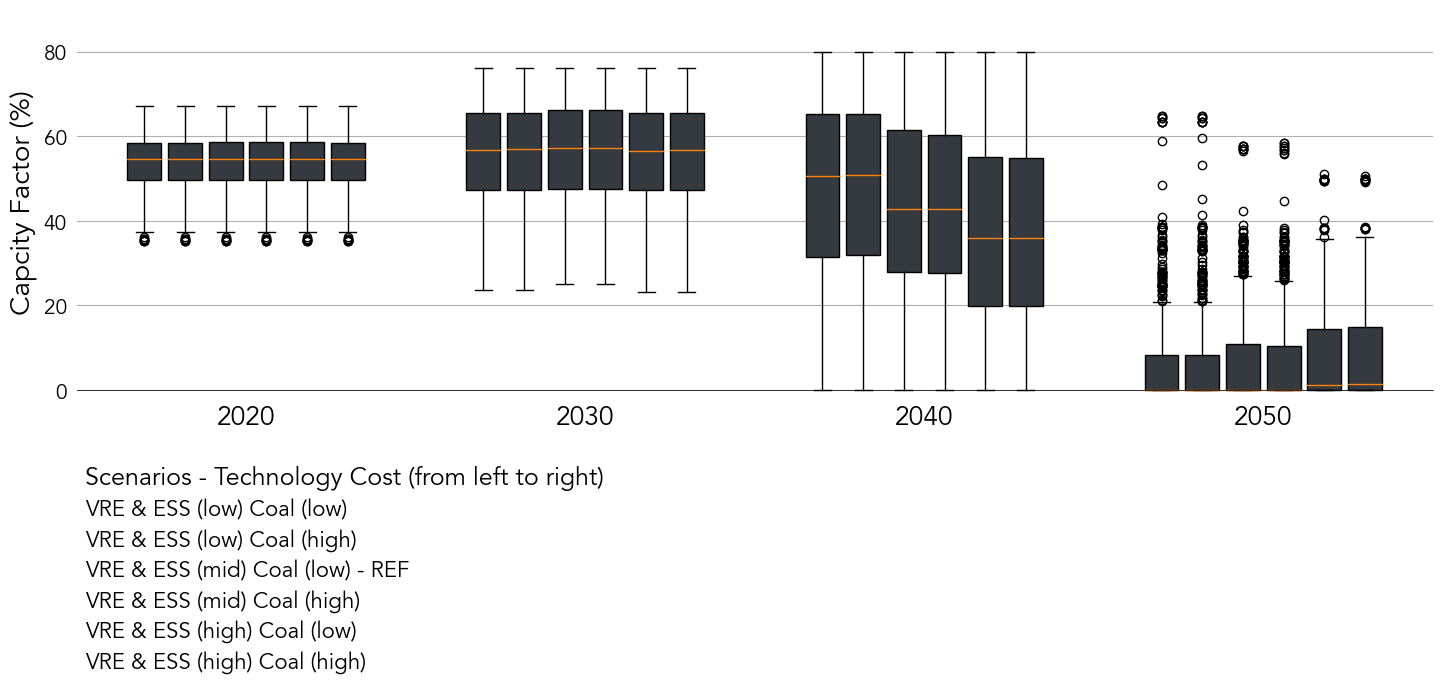

In [153]:
# Plot land use (MHa) for different scenarios
def _plot_system_capacity_factors(ax, df_, tech_labels_, scen_labels_, technology,
                                  ylabel = r'Capcity Factor (%)'):

    df_ = df_.loc[df_['technology'] == technology]

    scenarios_ = scen_labels_['scenario'].to_numpy()
    periods_   = np.sort(df_['period'].unique())

    x_  = np.linspace(0, .6, scenarios_.shape[0])
    x_ -= x_.mean()
    y_  = np.linspace(0, periods_.shape[0] - 1, periods_.shape[0])

    z_ = []
    w_ = []
    for period, i in zip(periods_, range(len(periods_))):
        print(period)
        for scenario, j in zip(scenarios_, range(len(scenarios_))):
            idx_ = (df_['period'] == period) & (df_['scenario'] == scenario)
            
            D_ = df_.loc[idx_, 'dispatch_mw'].to_numpy()
            C_ = df_.loc[idx_, 'potential_mw'].to_numpy()
            z  = y_[i] - x_[j]

            color = tech_labels_.loc[tech_labels_['group'] == technology, 'group_color'].to_numpy()[0]
            print((D_/C_).mean())
            ax.boxplot(100*D_/C_, 
                       positions    = [z], 
                       widths       = 0.1, 
                       patch_artist = True,
                       boxprops     = dict(facecolor = color))
            
            z_.append(z)
            
    ax.set_xticks(y_, periods_)

    ax.xaxis.set_tick_params(labelsize = 19, 
                             left      = False)
    
    ax.yaxis.set_tick_params(labelsize = 15, 
                             left      = False)

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.grid(axis = 'y')
    
    ax.axhline(0, linewidth = .5, 
                  linestyle = '-', 
                  color     = 'k', 
                  clip_on   = False, 
                  zorder    = 10)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    ax.set_ylim(-1, 90)
    ax.set_xlim(np.min(z_) - .2, np.max(z_) + .2)


fig, _ax = plt.subplots(1, 1, figsize = (17.5, 5))

_plot_system_capacity_factors(_ax, grouped_system_dispatch_, tech_labels_, scen_labels_, technology = 'Coal')

line1    = Line2D([], [], color = 'None')
handles_ = [line1, line1, line1, line1, line1, line1]
labels_  = list(scen_labels_['label'].to_numpy())

leg = _ax.legend(handles_, labels_, 
                 loc            = (0., -.75),
                 title          = 'Scenarios - Technology Cost (from left to right)',
                 frameon        = False,
                 labelspacing   = 0.25,
                 title_fontsize = 18,
                 handletextpad  = -1.,
                 ncol           = 1,
                 prop           = {'size': 16})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-cost-system_capacity_factor.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/SI-cost-system_capacity_factor.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [373]:
# def _group_dispatch_technologies(df_, tech_labels_):

#     for group in tech_labels_['group'].unique():
#         df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
#     df_ = df_.groupby(['period', 
#                        'technology', 
#                        'load_zone', 
#                        'scenario']).agg({'power_mw': 'sum'})
    
#     return df_.reset_index(drop = False)

# grouped_dispatch_ = _group_dispatch_technologies(dispatch_, tech_labels_)

# idx_ = grouped_dispatch_['technology'] == 'Battery'
# idx_ = idx_ | (grouped_dispatch_['technology'] == 'Hydrogen') 
# idx_ = idx_ | (grouped_dispatch_['technology'] == 'Pumped Storage')

# grouped_dispatch_ = grouped_dispatch_.loc[~idx_].reset_index(drop = True)
# grouped_dispatch_ = grouped_dispatch_.fillna(0.)
# print(grouped_dispatch_)

      period technology       load_zone  \
0       2020       Coal  Andhra_Pradesh   
1       2020       Coal  Andhra_Pradesh   
2       2020       Coal           Assam   
3       2020       Coal           Assam   
4       2020       Coal           Bihar   
...      ...        ...             ...   
1163    2050       Wind       Telangana   
1164    2050       Wind   Uttar_Pradesh   
1165    2050       Wind   Uttar_Pradesh   
1166    2050       Wind     West_Bengal   
1167    2050       Wind     West_Bengal   

                                               scenario      power_mw  
0     VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90C...  3.572126e+06  
1     VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90C...  3.572126e+06  
2     VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90C...  0.000000e+00  
3     VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90C...  0.000000e+00  
4     VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90C...  1.936278e+06  
...                                                

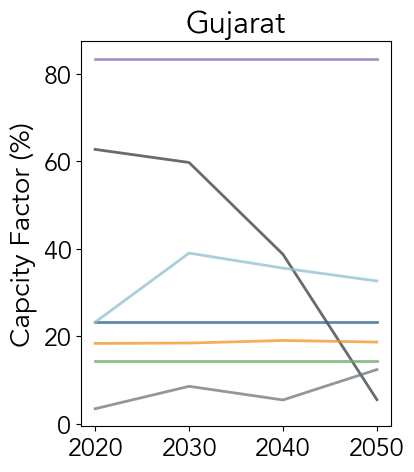

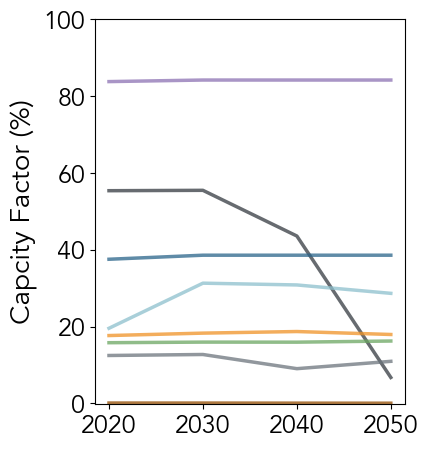

In [395]:
# Plot land use (MHa) for different scenarios
def _plot_capacity_factors(ax, df_1_, df_2_, tech_labels_, scen, 
                           load_zone    = None,
                           ylabel       = r'Capcity Factor (%)',
                           legend_title = 'Resource'):
    
    if load_zone == None:
        df_1_ = df_1_.groupby(['period', 
                               'technology', 
                               'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)
    
        df_2_ = df_2_.groupby(['period', 
                               'technology', 
                               'scenario']).agg({'capacity_mw': 'sum'}).reset_index(drop = False)
        
    df_1p_ = df_1_.loc[(df_1_['scenario'] == scen)].reset_index(drop = True)    
    df_2p_ = df_2_.loc[(df_2_['scenario'] == scen)].reset_index(drop = True)    
    
    for tech in df_1p_['technology'].unique():  
        df_1pp_ = df_1p_.loc[df_1p_['technology'] == tech].sort_values(by = ['period']).reset_index(drop = True)
        df_2pp_ = df_2p_.loc[df_2p_['technology'] == tech].sort_values(by = ['period']).reset_index(drop = True)
        color   = tech_labels_.loc[tech_labels_['group'] == tech, 'group_color'].to_numpy()[0]
        
        cf_ = 100.*(df_1pp_['power_mw']/(df_2pp_['capacity_mw']*24*24))

        ax.plot(df_2pp_['period'], cf_, 
                label = tech,
                color = color,
                alpha = 0.75, 
                lw    = 2.5)
    
    ax.set_ylim(-.25, 100)
    ax.xaxis.set_tick_params(labelsize = 18)
    ax.yaxis.set_tick_params(labelsize = 18)
    ax.set_ylabel(ylabel, fontsize = 20)


scen = 'VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90CAP_500GW_PIERmid-month'

fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_capacity_factors(ax, grouped_dispatch_, grouped_capacity_, tech_labels_, scen)

plt.show()

In [393]:
print(scen_labels_['scenario'].unique())

['VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90CAP_500GW_PIERmid-day'
 'VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90CAP_500GW_PIERmid-month']


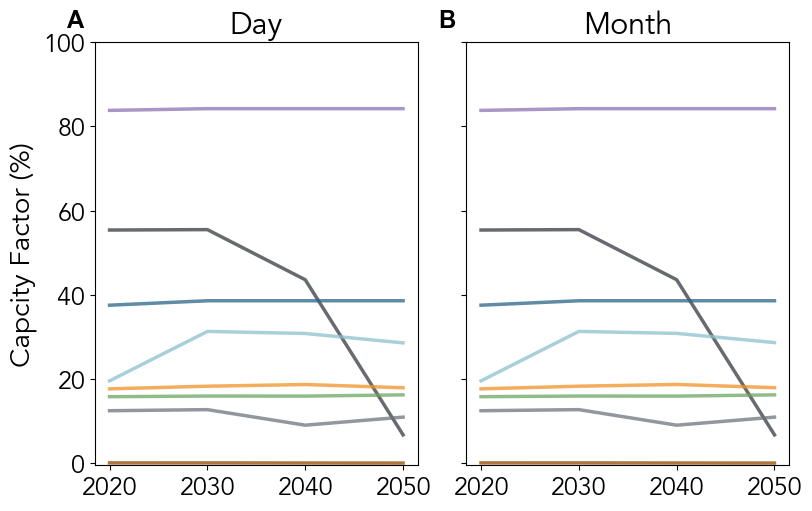

In [394]:

fig, _ax = plt.subplot_mosaic([['A', 'B']], layout      = 'constrained', 
                                            sharey      = True,
                                            sharex      = True,
                                            figsize     = (8, 5), 
                                            gridspec_kw = {'width_ratios': [1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
                             fontsize  = 'xx-large', 
                             weight    = "bold",
                             va        = 'bottom',
                             family    = 'Arial')

scen = 'VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90CAP_500GW_PIERmid-day'

_plot_capacity_factors(_ax['A'], grouped_dispatch_, grouped_capacity_, tech_labels_, scen)

label = scen_labels_.loc[scen_labels_['scenario'] == scen, 'label'].to_numpy()[0]

_ax['A'].set_title(f'{label}', fontsize = 22)

scen = 'VREmid_STmid_CONVmid_H2_RES_10PRM_CC_50RPS_90CAP_500GW_PIERmid-month'

_plot_capacity_factors(_ax['B'], grouped_dispatch_, grouped_capacity_, tech_labels_, scen, ylabel = '')

label = scen_labels_.loc[scen_labels_['scenario'] == scen, 'label'].to_numpy()[0]

_ax['B'].set_title(f'{label}', fontsize = 22)

# plt.savefig(path_to_images + f'/system_level-capacity_factors.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

# plt.savefig(path_to_images + f'/system_level-capacity_factors.pdf', 
#             bbox_inches = 'tight', 
#             dpi         = 600)

plt.show()

# Demand profiles verification

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDhigh /Users/Guille/Desktop/india_power/scenarios/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDlow /Users/Guille/Desktop/india_power/scenarios/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/demand


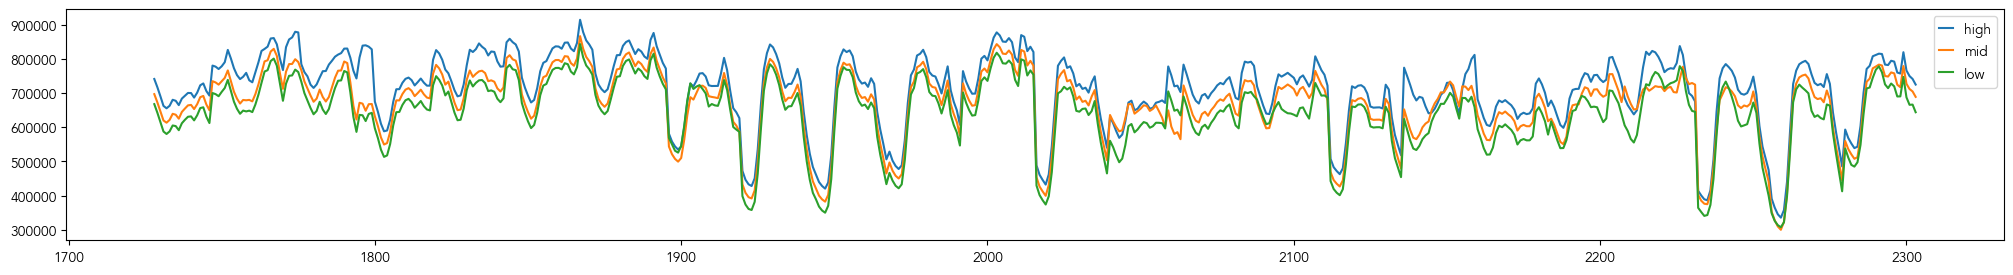

In [7]:
# Grab data from databases for plotting energy dispatch and clean energy targets
def _system_load(scen, path):

    # Load energy dispatch table and process data from database
    def __system_load_from_csv(df_, scenario):

        df_ = df_[['period', 'static_load_mw', 'load_zone', 'timepoint', 'timepoint_weight']]
        
        df_ = df_.groupby(['period', 
                           'timepoint_weight',
                           'timepoint']).agg({'static_load_mw': 'sum'}).reset_index(drop = False)
                        
        return df_


    print(scen, path)

    dir_name = r'{}/{}'.format(path, scen)
    load_    = pd.read_csv(dir_name + f'/results/system_load_zone_timepoint.csv', 
                           low_memory = False)


    return __system_load_from_csv(load_, scen).reset_index(drop = True)

period = 2050

path = '/Users/Guille/Desktop/india_power/scenarios/demand'

scen = 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDhigh'
# ICED: Peak=914646, Demand=5960
# PIER: Peak=1015048, Demand=5956

system_load_      = _system_load(scen, path)
system_load_high_ = system_load_.loc[system_load_['period'] == period]

scen = 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDlow'
# ICED: Peak=843564, Demand=5348
# PIER: Peak=963099, Demand=5341

system_load_     = _system_load(scen, path)
system_load_low_ = system_load_.loc[system_load_['period'] == period]

path = '/Users/Guille/Desktop/india_power/scenarios/demand'

scen = 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid'
# ICED: Peak=866876, Demand=5608
# PIER: Peak=977401, Demand=5603

system_load_     = _system_load(scen, path)
system_load_mid_ = system_load_.loc[system_load_['period'] == period]


plt.figure(figsize = (25, 3))
plt.plot(system_load_high_['static_load_mw'], label = 'high')
plt.plot(system_load_mid_['static_load_mw'], label = 'mid')
plt.plot(system_load_low_['static_load_mw'], label = 'low')
plt.legend()

plt.savefig('PIER_2030.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [8]:
print(np.max(system_load_high_['static_load_mw']))
print(np.sum(system_load_high_['static_load_mw'] * system_load_high_['timepoint_weight'])/1e6)

914646.1406099664
6002.0096680646475


In [9]:
print(np.max(system_load_mid_['static_load_mw']))
print(np.sum(system_load_mid_['static_load_mw'] * system_load_mid_['timepoint_weight'])/1e6)

866876.6205881521
5645.247683431127


In [10]:
print(np.max(system_load_low_['static_load_mw']))
print(np.sum(system_load_low_['static_load_mw'] * system_load_low_['timepoint_weight'])/1e6)

843564.2754746546
5381.173323398536


In [ ]:
# peak = 622211, demand = 4,015 TWh
# peak = 636754, demand = 4,177 TWh

In [40]:
# Grab data from databases for plotting energy dispatch and clean energy targets
def _availability(scen, path):

    # Load energy dispatch table and process data from database
    def __availbility_from_csv(df_):

        df_ = df_[['project', 
                   'period', 
                   'technology',
                   'availability_derate', 
                   'timepoint', 
                   'capacity_mw', 
                   'power_mw',
                   'timepoint_weight']]

        df_['power_mw'] = df_['power_mw']*df_['timepoint_weight']
                 
        return df_
        _
    print(scen, path)

    dir_name  = r'{}/{}'.format(path, scen)
    projects_ = pd.read_csv(dir_name + f'/results/project_timepoint.csv', 
                            low_memory = False)

    return __availbility_from_csv(projects_).reset_index(drop = True)

period = 2050
tech   = 'CT'

path   = '/Users/Guille/Desktop/india_power/scenarios/demand'
scen   = 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDhigh'

availability_ = _availability(scen, path)
idx_          = (availability_['technology'] == tech) & (availability_['period'] == period)
availability_ = availability_.loc[idx_].reset_index(drop = True)

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDhigh /Users/Guille/Desktop/india_power/scenarios/demand


/var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_8517/894857541.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_['power_mw'] = df_['power_mw']*df_['timepoint_weight']


CT_AP_new
4837.420499539883 4.139301584035062 1754062.308667687


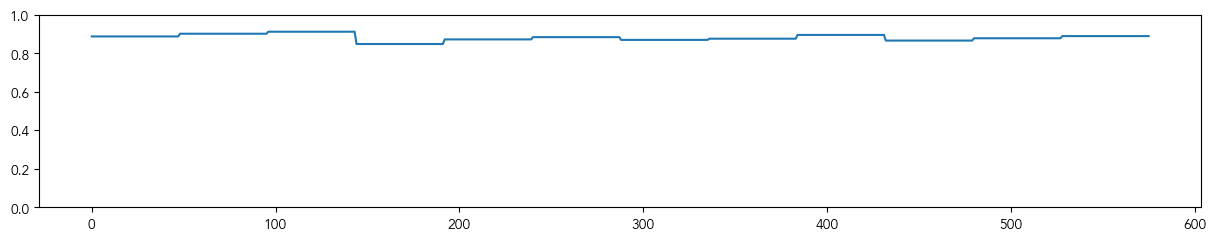

CT_DL_new
CT_GJ_new
CT_HR_new
CT_JK_new
CT_KL_new
1337.0106123738533 4.1170011474438555 482191.94213520834


/var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_8517/539709594.py:7: RuntimeWarning: invalid value encountered in double_scalars
  cf  = 100*gen/(cap*8760)


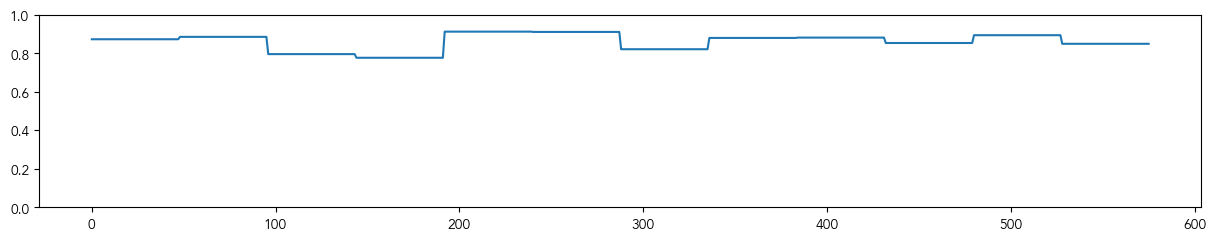

CT_MH_new
CT_RJ_new
CT_TN_new
9381.029369029657 0.5789593786698543 475776.18028647086


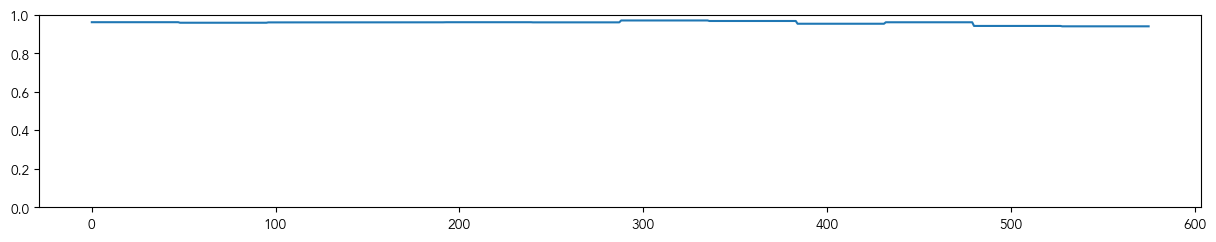

CT_TR_new
CT_UP_new
CT_WB_new
5584.491761048453 4.652479898295026 2276000.043857358


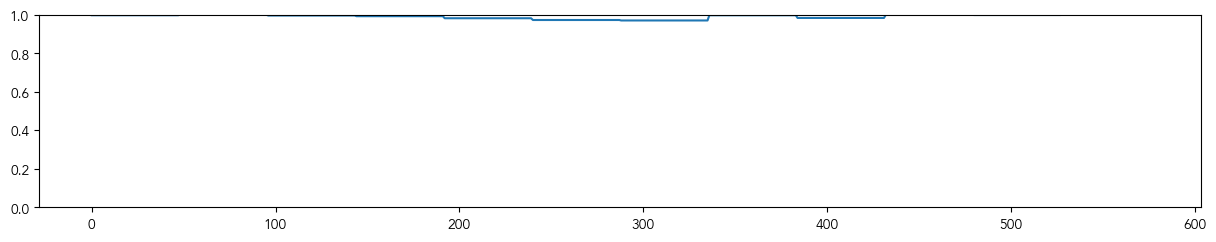

21139.952241991847


In [41]:
cap_tll = 0
for project in availability_['project'].unique():
    print(project)
    df_ = availability_.loc[availability_['project'] == project].reset_index(drop = True)
    cap = df_['capacity_mw'].unique()[0]
    gen = df_['power_mw'].sum()
    cf  = 100*gen/(cap*8760)
    if cap > 0.:
        print(cap, cf, gen)
        plt.figure(figsize = (15, 2.5))
        plt.plot(df_['availability_derate'])
        plt.ylim(0,1)
        plt.show()
    cap_tll += cap
print(cap_tll)